## test optimize

In [1]:
# setup imports
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path().resolve().parents[2]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

In [2]:
import cma
from ewatercycle.observation.grdc import get_grdc_data

from src.forcing import load_lumped_forcing
from src.models import *
from src.paths import *

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


In [3]:
ERA5_forcing_loaded = load_lumped_forcing("Kerki_GRDC", "ERA5", "1959-1963")
# plot_ERA5_forcing(ERA5_forcing_loaded)

In [4]:
theta_test = np.mean(generate_HBV_parameters(100), axis=0)

grdc_station = get_grdc_data(
    2617110, "1959-01-02T00:00Z", "1963-12-31T00:00Z", data_home=GRDC / "Daily"
)

q_obs = grdc_station["streamflow"]
years = q_obs["time"].dt.year.values
shape_name = "Kerki_GRDC"

In [5]:
J = objective(
    theta_test,
    forcing=ERA5_forcing_loaded,
    q_obs=q_obs,
    years=years,
    shape_name=shape_name,
)

print("Objective value:", J)

Objective value: 3.810862699738292


In [6]:
grdc_station = get_grdc_data(
    2617110, "1959-01-01T00:00Z", "1963-12-31T00:00Z", data_home=GRDC / "Daily"
)

obs = grdc_station["streamflow"]

In [7]:
# J_val = float(J)   # converts xarray.DataArray to a plain Python float
# print("Objective value:", J_val)

In [8]:
# # run safe test with maxfun=5
# res = minimize(
#     objective_safe,
#     x0=theta_test,
#     args=(ERA5_forcing_loaded, q_obs.values, years, shape_name),
#     method="Powell",
#     bounds=bounds,
#     options={"maxiter": 5, "disp": True}
# )

# print("Test run completed")
# print("Best theta found (approx):", res.x)
# print("Objective value:", res.fun)

In [9]:
# x0_norm = scale(0.5 * (p_min + p_max))  # middle of normalized range

# res = cma.fmin(
#     objective_safe,
#     x0_norm,
#     sigma0=0.1,
#     args=(ERA5_forcing_loaded, q_obs.values, years, shape_name),
#     options={
#         'bounds': [np.zeros_like(p_min).tolist(), np.ones_like(p_max).tolist()],
#         'popsize': 5,
#         'maxfevals': 30
#     }
# )

In [10]:
# CMA-ES test setup
x0_norm = scale(0.5 * (p_min + p_max))  # start in the middle
sigma0 = 0.1  # step size in normalized space

res = cma.fmin(
    objective_safe,
    x0_norm,
    sigma0,
    args=(ERA5_forcing_loaded, q_obs.values, shape_name),
    options={
        "bounds": [np.zeros_like(p_min).tolist(), np.ones_like(p_max).tolist()],
        "popsize": 15,
        "maxfevals": 500,
    },
)

(7_w,15)-aCMA-ES (mu_w=4.5,w_1=34%) in dimension 9 (seed=214025, Thu Jan 22 15:10:54 2026)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     15 4.963309599201035e-01 1.0e+00 1.06e-01  1e-01  1e-01 1:29.6
    2     30 3.777152697975462e-01 1.4e+00 1.19e-01  1e-01  1e-01 2:58.6
    3     45 2.269466007659653e-01 1.7e+00 1.35e-01  1e-01  1e-01 4:30.5
    4     60 2.175763940866515e-01 1.7e+00 1.42e-01  1e-01  2e-01 6:00.1
    5     75 2.115044697987594e-01 1.6e+00 1.41e-01  1e-01  2e-01 7:30.1
    6     90 1.960854104933956e-01 1.6e+00 1.28e-01  1e-01  1e-01 8:59.7
    7    105 2.155435706140317e-01 1.7e+00 1.18e-01  1e-01  1e-01 10:28.3
    8    120 1.914049717128586e-01 1.8e+00 1.13e-01  9e-02  1e-01 11:58.5
    9    135 1.827796882773039e-01 1.9e+00 1.04e-01  8e-02  1e-01 13:28.1
   10    150 1.769265734639486e-01 2.0e+00 9.53e-02  7e-02  1e-01 14:57.3
   11    165 1.753507158120352e-01 2.1e+00 8.68e-02  6e-02  9e-02 16:26.7
   12    180 1.84497208343660

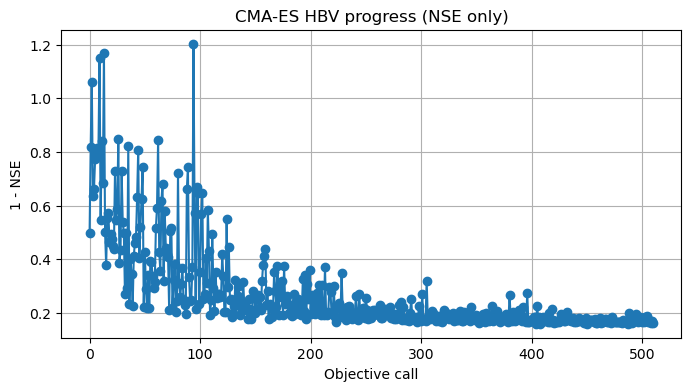

In [11]:
import pandas as pd

# convert history to DataFrame for analysis
history_df = pd.DataFrame(
    {
        "objective": history["objective"],
        **{f"theta_{i}": [th[i] for th in history["theta_phys"]] for i in range(len(p_min))},
    }
)

# quick plot example

plt.figure(figsize=(8, 4))
plt.plot(history_df["objective"], marker="o")
plt.xlabel("Objective call")
plt.ylabel("1 - NSE")
plt.title("CMA-ES HBV progress (NSE only)")

plt.grid(True)
plt.show()

# # parameter scatter plot example
# plt.figure(figsize=(10,5))
# for i in range(len(p_min)):
#     plt.plot(history_df[f"theta_{i}"], label=f"param_{i}")
# plt.xlabel("Objective call")
# plt.ylabel("Parameter value")
# plt.title("HBV parameters during CMA-ES")
# plt.legend()
# plt.show()

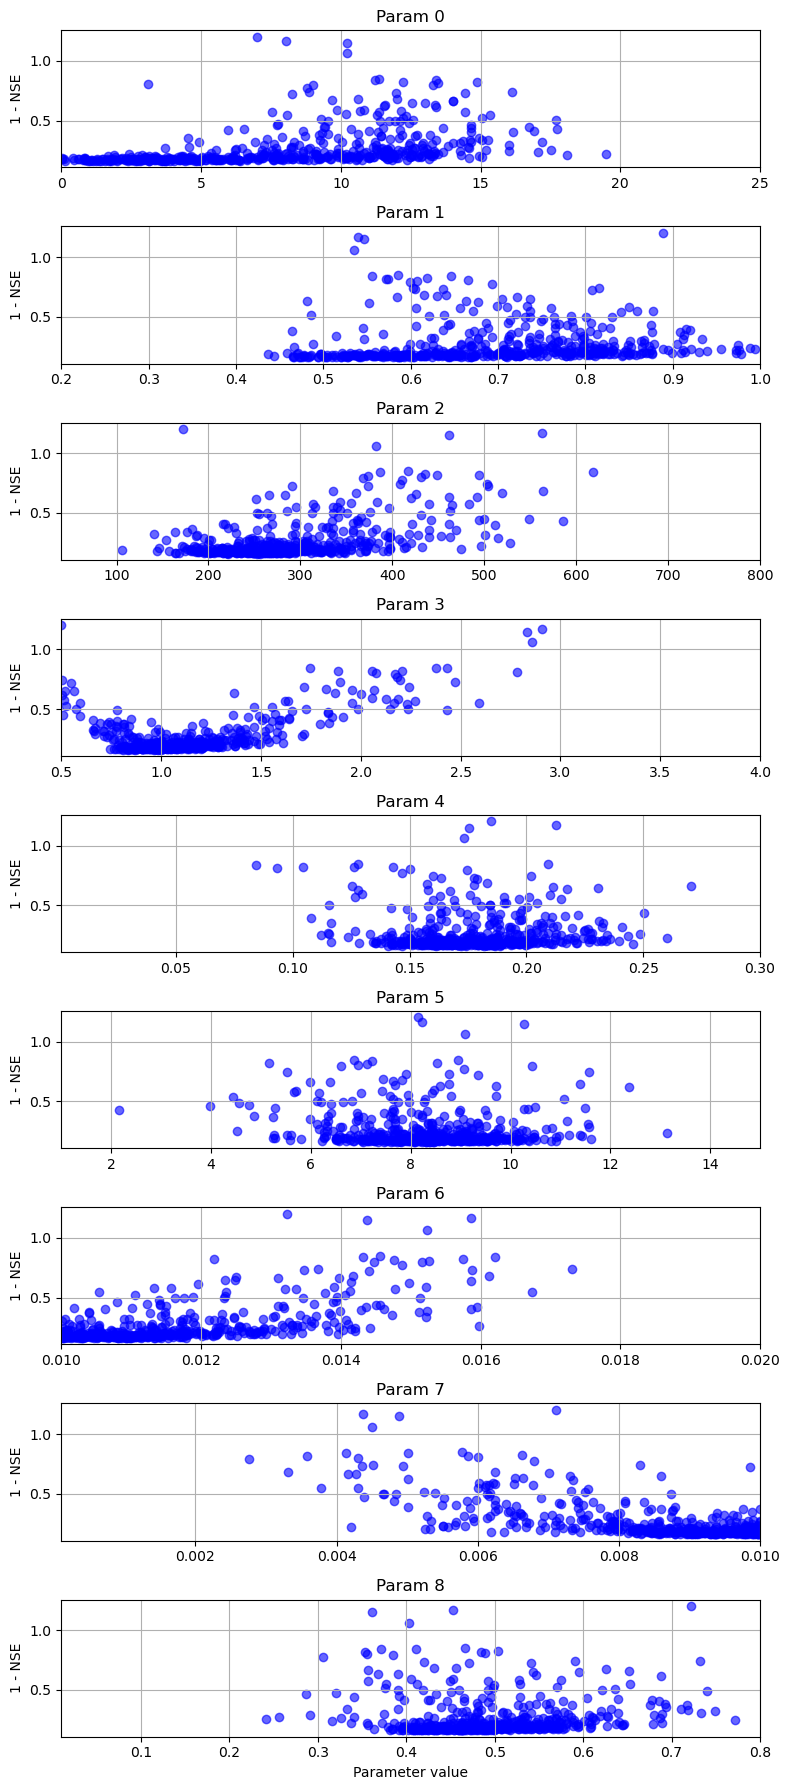

In [12]:
import matplotlib.pyplot as plt

n_params = len(p_min)
fig, axes = plt.subplots(n_params, 1, figsize=(8, 2 * n_params), sharex=False)

for i in range(n_params):
    ax = axes[i]
    ax.scatter(history_df[f"theta_{i}"], history_df["objective"], c="blue", alpha=0.6)
    ax.set_ylabel("1 - NSE")
    ax.set_title(f"Param {i}")
    ax.set_xlim(p_min[i], p_max[i])  # set x-axis limits per parameter
    ax.grid(True)

axes[-1].set_xlabel("Parameter value")
plt.tight_layout()
plt.show()

In [13]:
x_norm = res[0]  # or res.x depending on your CMA-ES call

# convert back to physical parameter space
theta_phys = unscale(x_norm)

print("Physical HBV parameters:")
for i, th in enumerate(theta_phys):
    print(f"Param {i}: {th:.4f}")

Physical HBV parameters:
Param 0: 3.8900
Param 1: 0.5004
Param 2: 252.8308
Param 3: 0.8324
Param 4: 0.1886
Param 5: 7.4591
Param 6: 0.0103
Param 7: 0.0098
Param 8: 0.4299


In [14]:
import numpy as np

# normalized incumbent solution
x_norm = np.array(res[5])

# unscale to physical parameter values
theta_phys = unscale(x_norm)

# print nicely
for i, th in enumerate(theta_phys):
    print(f"{parameter_names[i]}: {th:.4f}")

Imax: 2.6453
Ce: 0.5426
Sumax: 248.8886
Beta: 0.9044
Pmax: 0.1642
Tlag: 8.4733
Kf: 0.0113
Ks: 0.0094
FM: 0.4447


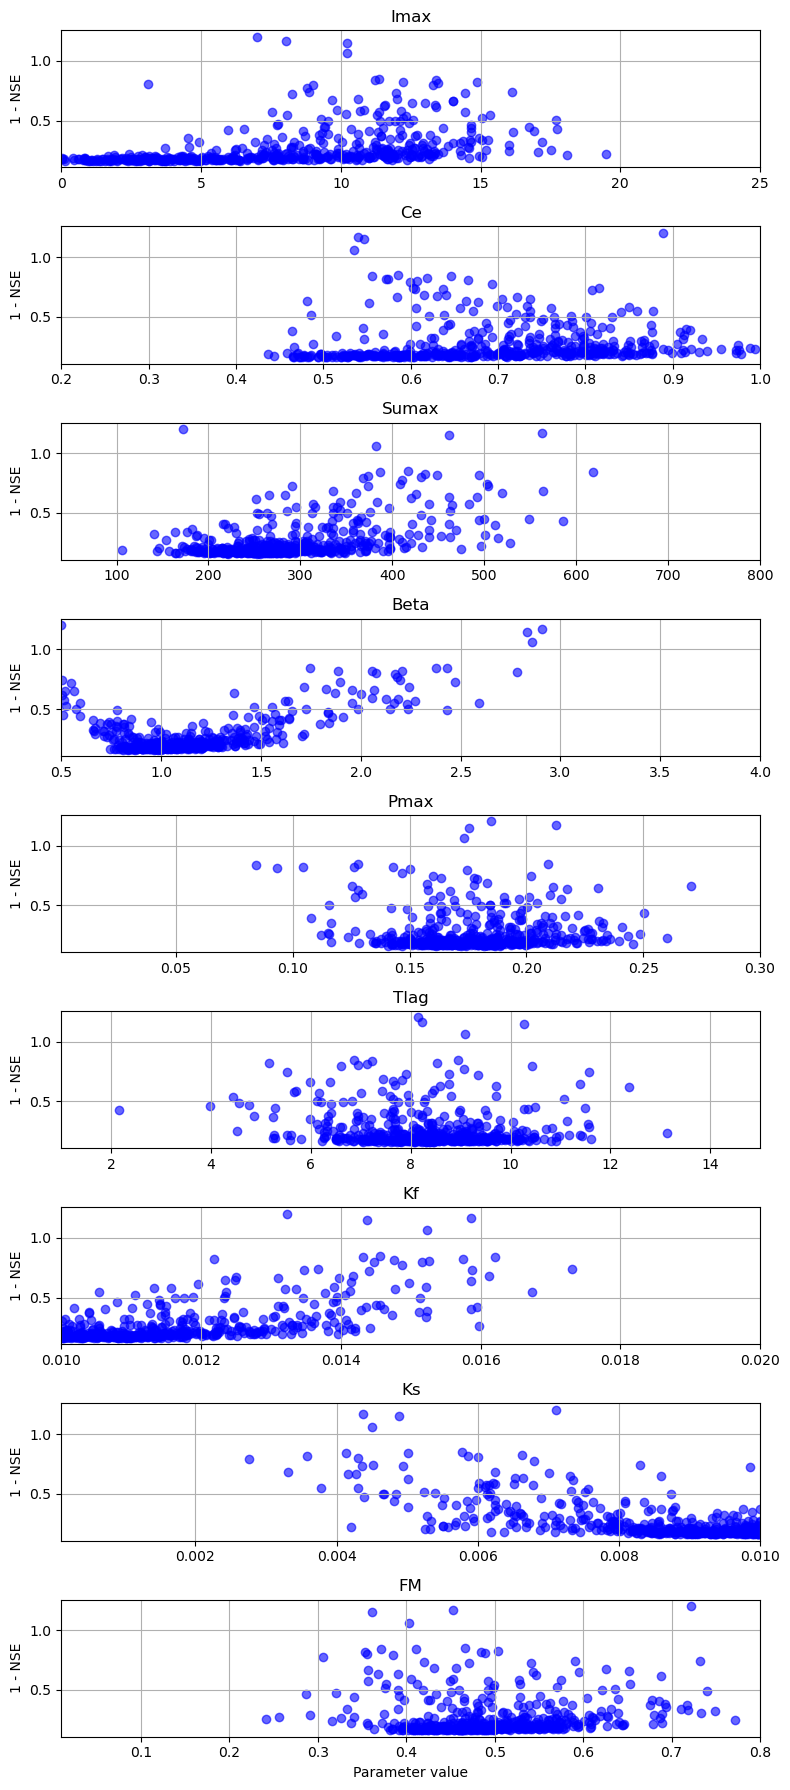

In [15]:
n_params = len(p_min)
fig, axes = plt.subplots(n_params, 1, figsize=(8, 2 * n_params), sharex=False)

for i in range(n_params):
    ax = axes[i]
    ax.scatter(history_df[f"theta_{i}"], history_df["objective"], c="blue", alpha=0.6)
    ax.set_ylabel("1 - NSE")
    ax.set_title(parameter_names[i])  # use actual parameter name
    ax.set_xlim(p_min[i], p_max[i])  # set x-axis limits per parameter
    ax.grid(True)

axes[-1].set_xlabel("Parameter value")
plt.tight_layout()
plt.show()

In [16]:
res

(array([0.15559825, 0.37544475, 0.28004055, 0.09497733, 0.62752286,
        0.46136079, 0.02519893, 0.97929834, 0.53150699]),
 0.15935036190698884,
 405,
 511,
 34,
 array([0.10581224, 0.42829205, 0.27485336, 0.11554731, 0.54585718,
        0.53380636, 0.13451876, 0.93528858, 0.55019133]),
 array([0.06499099, 0.06872428, 0.04220584, 0.02305119, 0.04388011,
        0.04538708, 0.05527207, 0.05332783, 0.04079805]),
 {'maxfevals': 500},
 {'maxfevals': 500},
 <cma.logger.CMADataLogger at 0x7f3e0ec19d30>)

In [17]:
history_df = pd.DataFrame(history)
history_df.tail()

,theta_norm,theta_phys,objective,nse,kge,vol_err
506,"[0.14521767069968197, 0.38734285750258096, 0.1...","[3.6304417674920493, 0.5098742860020649, 190.1...",0.175022,0.646478,0.816673,0.034919
507,"[0.06951270331402812, 0.5393347715799217, 0.21...","[1.737817582850703, 0.6314678172639374, 203.03...",0.167988,0.635339,0.820368,0.011751
508,"[0.10811490405293704, 0.4000659733948103, 0.29...","[2.702872601323426, 0.5200527787158482, 267.22...",0.163168,0.638489,0.822055,0.003328
509,"[0.13407287874621143, 0.517183563019636, 0.281...","[3.351821968655286, 0.6137468504157089, 254.00...",0.169817,0.624440,0.815620,0.004587
510,"[0.10581224455236031, 0.42829204883537814, 0.2...","[2.6453061138090077, 0.5426336390683025, 248.8...",0.162672,0.639240,0.822416,0.002922


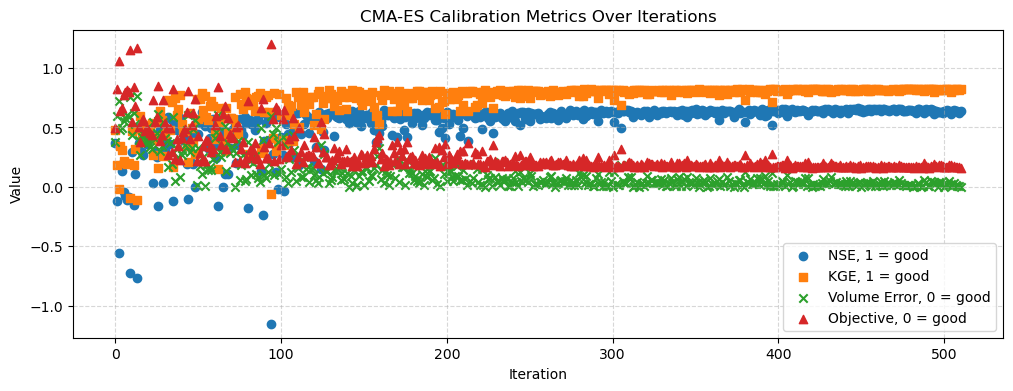

In [ ]:
# Assuming history_df is already created
plt.figure(figsize=(12, 4))

plt.scatter(history_df.index, history_df["nse"], label="NSE, 1 = good", marker="o")
plt.scatter(history_df.index, history_df["kge"], label="KGE, 1 = good", marker="s")
plt.scatter(history_df.index, history_df["vol_err"], label="Volume Error, 0 = good", marker="x")
plt.scatter(history_df.index, history_df["objective"], label="Objective, 0 = good", marker="^")

plt.xlabel("F_eval")
plt.ylabel("Value")
plt.title("CMA-ES Calibration Metrics")
plt.legend()
plt.grid(linestyle="--", alpha=0.5)
plt.show()

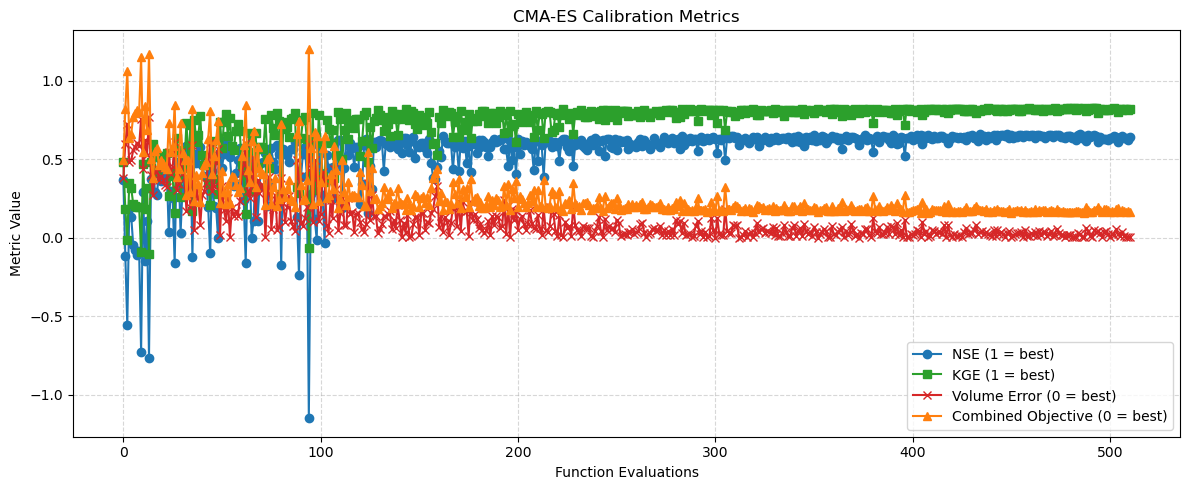

In [41]:
plt.figure(figsize=(12, 5))

# NSE and KGE
plt.plot(history_df.index, history_df["nse"], label="NSE (1 = best)", marker="o", color="tab:blue")
plt.plot(history_df.index, history_df["kge"], label="KGE (1 = best)", marker="s", color="tab:green")

# Volume error and objective (flipped so 1 = bad, 0 = good)
plt.plot(
    history_df.index,
    history_df["vol_err"],
    label="Volume Error (0 = best)",
    marker="x",
    color="tab:red",
)
plt.plot(
    history_df.index,
    history_df["objective"],
    label="Combined Objective (0 = best)",
    marker="^",
    color="tab:orange",
)

plt.xlabel("Function Evaluations")
plt.ylabel("Metric Value")
plt.title("CMA-ES Calibration Metrics")
plt.legend()
plt.grid(linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [43]:
# normalized incumbent solution
x_norm = np.array(res[5])

# unscale to physical parameter values
theta_phys = unscale(x_norm)

initial_conditions = np.array(
    [
        0,  # Si
        100,  # Su
        0,  # Sf
        5,  # Ss
        100,  # Sp
    ]
)

final_run = run_HBV_model(ERA5_forcing_loaded, theta_phys, initial_conditions, show_progress=True)

Running HBV model:   0%|          | 0/1825 [00:00<?, ?it/s]

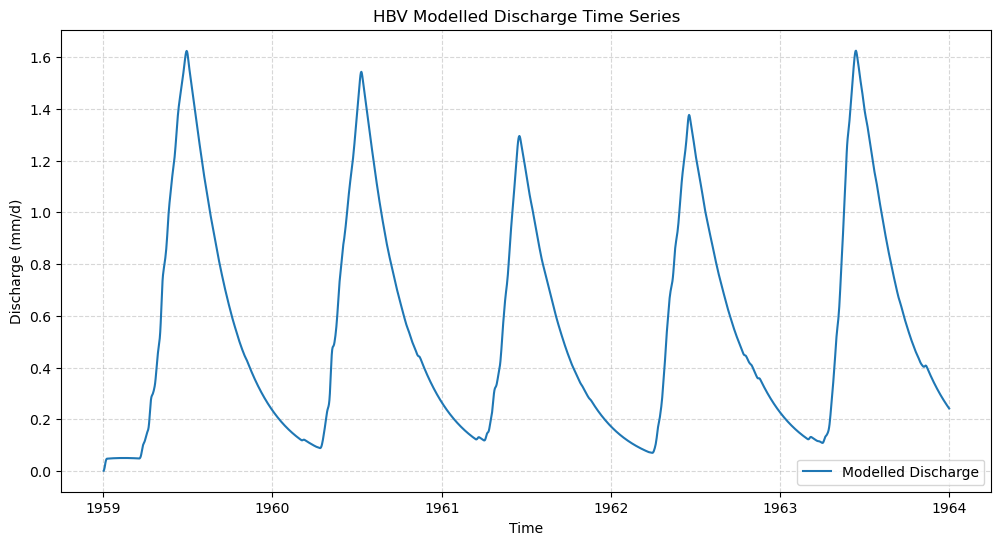

In [44]:
plot_HBV_output(final_run)

In [21]:
model_output_m3 = mmday_to_m3s(final_run, shape_name)

3134612.0
3125452.4658816047


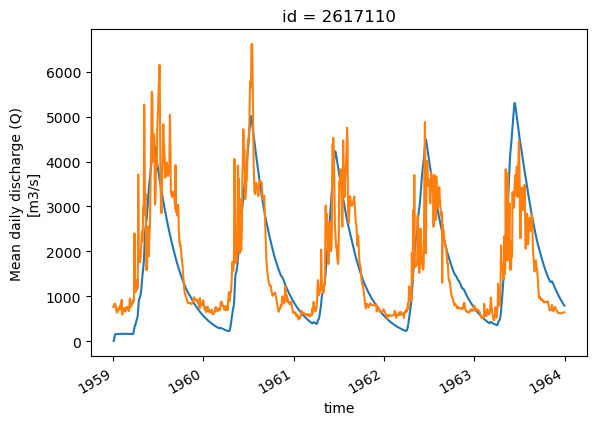

In [34]:
model_output_m3.plot()
q_obs.plot()

print(np.sum(q_obs.values))
print(np.sum(model_output_m3))

In [37]:
save_history(history, "first_full_run", fmt="csv")

History saved to results/first_full_run.csv
